In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
import os
from torchvision import transforms
from transformers import AutoModel, AutoTokenizer
from diffusers import AutoencoderDC
import matplotlib.pyplot as plt
import random
from PIL import Image
from torchvision.models import vgg16
import pandas as pd
from combinationFnBlock import TimeEmbedding, AdaptiveLayerNorm, Rotary2DPositionalEncoding, PatchEmbedding, ScaleBlock, ScaleShiftBlock, FeedForwardBlock
import torch.nn.functional as Fn
from einops import rearrange
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from torchviz import make_dot


 The Device is : cpu


In [2]:
if(torch.cuda.is_available()):
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

torch.autograd.set_detect_anomaly(True)
print("Device: ", device)

Device:  cpu


In [3]:
DCAEENCODER = AutoencoderDC.from_pretrained(f"mit-han-lab/dc-ae-f64c128-in-1.0-diffusers", torch_dtype=torch.float32).to(device).eval()
VGG_MODEL = vgg16(pretrained=True).features[:17].eval().to(device)

modelPath = "./models/"
os.makedirs(modelPath, exist_ok=True)
# BGEDIR = os.path.join(modelPath, "bge-base-en-v1.5")
# NMCDIR = os.path.join(modelPath, "nomic-embed-text-v1")
QWENDIR = os.path.join(modelPath, "qwen3-embedding-8b")
# AutoTokenizer.from_pretrained("BAAI/bge-base-en-v1.5").save_pretrained(BGEDIR)
# AutoModel.from_pretrained("BAAI/bge-base-en-v1.5").save_pretrained(BGEDIR)
# AutoTokenizer.from_pretrained("nomic-ai/nomic-embed-text-v1").save_pretrained(NMCDIR)
# AutoModel.from_pretrained("nomic-ai/nomic-embed-text-v1", trust_remote_code=True).save_pretrained(NMCDIR)
AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-8B").save_pretrained(QWENDIR)
AutoModel.from_pretrained("Qwen/Qwen3-Embedding-8B").save_pretrained(QWENDIR)

# BGETOKENIZER = AutoTokenizer.from_pretrained(BGEDIR, local_files_only=True)
# BGEMODEL = AutoModel.from_pretrained(BGEDIR, local_files_only=True)
# NMCTOKENIZER = AutoTokenizer.from_pretrained(NMCDIR, local_files_only=True)
# NMCMODEL = AutoModel.from_pretrained(NMCDIR, trust_remote_code=True, local_files_only=True)
QWEN3TOKENIZER = AutoTokenizer.from_pretrained(QWENDIR, local_files_only=True)
QWEN3MODEL = AutoModel.from_pretrained(QWENDIR, local_files_only=True)


/Users/ishananand/miniforge3/envs/pytorch_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ishananand/miniforge3/envs/pytorch_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [4]:
def concatenateTextEmbeddings(text, maxLength = 512, modelPath = "./models"):
    if isinstance(text, str):
        text = [text]
    elif isinstance(text, (list, tuple)):
        pass
    else:
        raise ValueError(f"Give string or list of strings, recieved this {type(text)}")
    
    input3 = QWEN3TOKENIZER(text, padding='max_length', return_tensors="pt", truncation=True, max_length=maxLength)

    with torch.no_grad():
        output3 = QWEN3MODEL(**input3)
        embeddings3 = output3.last_hidden_state
    
    textEmbeddings = embeddings3#torch.cat([embeddings1, embeddings2, embeddings3], dim=-1)
    return textEmbeddings


def EncodeImageDCAE(image):
    latents = DCAEENCODER.encode(image).latent
    return latents


def DecodeImageDCAE(image, deNormalize = False):
    decoded = DCAEENCODER.decode(image).sample
    if deNormalize:
        decoded = decoded * 0.5 + 0.5

    return decoded

class PretrainedEncodeImage(nn.Module):
    def __init__(self, pretrainedModel = "mit-han-lab/dc-ae-f64c128-in-1.0-diffusers"):
        super().__init__()
        # self.dcaeEncoder = AutoencoderDC.from_pretrained(pretrained_model_name_or_path=pretrainedModel, torch_dtype = torch.float32).to(device)
        
    def decodeImage(self, x, deNormalize = False):
        with torch.no_grad():
            decodedLatents = DCAEENCODER.decode(x).sample
        
        if deNormalize:
            decodedLatents = decodedLatents * 0.5 + 0.5
        
        return decodedLatents

    def forward(self, x):
        with torch.no_grad():
            encodedLatents = DCAEENCODER.encode(x).latent

        return encodedLatents

preprocessImage = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class ImageTextDataset(Dataset):
    def __init__(self, data, transform = None, rootDir = ""):
        super().__init__()
        self.data = data
        self.transform = transform
        self.rootDir = rootDir
        self.latentCache = {}
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        row = self.data.iloc[index]

        image_path = os.path.join(self.rootDir, row['imagePath'])
        captions = [
            row['caption1'],
            row['caption2'],
            row['caption3'],
            row['caption4'],
            row['caption5']
        ]

        caption = random.choice(captions)
        if index in self.latentCache:
            image = self.latentCache[index]
        else:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
            
            # Cache if not too many images cached (prevent OOM)
            if len(self.latentCache) < 1000:
                self.latentCache[index] = image


        # image = Image.open(image_path).convert("RGB")
        # image = self.transform(image)
        
        # if(len(image) == 3):
        #     image = image.unsqueeze(0)

        noise = torch.randn_like(image)
        textEmbed = concatenateTextEmbeddings(caption)
        
        return image, textEmbed, noise

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),                 
    transforms.Normalize([0.5]*3, [0.5]*3)])



In [5]:
class ConcatenateImgTextMLP(nn.Module):
    def __init__(self, textinputDimension, encodedChannels = 128,  embedDimension = 768, imageSize = 8, patchSize = 4):
        super().__init__()

        self.patchEmbed = PatchEmbedding(imageSize= imageSize, patchSize=2, inChannels=encodedChannels, embedDimension=embedDimension)

        self.embedDimension = embedDimension
        self.inputDimension = textinputDimension
        self.encodedChannels = encodedChannels

        self.rope2DPos = Rotary2DPositionalEncoding(patchSize, patchSize, encodedChannels)


        self.textlayer1 = nn.Linear(textinputDimension, textinputDimension//2)
        self.textlayer2 = nn.Linear(textinputDimension//2, embedDimension)
        self.text_projection = nn.Linear(self.embedDimension, self.embedDimension)

        self.imagelayer1 = nn.Linear(self.encodedChannels, self.encodedChannels * 2)
        self.imagelayer2 = nn.Linear(self.encodedChannels * 2, embedDimension)

        self.textNorm = nn.LayerNorm(embedDimension)
        self.imageNorm = nn.LayerNorm(embedDimension)

        self.modalityEmbeds = nn.Embedding(2, embedding_dim=embedDimension)
        self.gelu = nn.GELU()

        self.fusion = nn.Linear(embedDimension, embedDimension)


    def forward(self, image, text):
        batchSize = image.shape[0]
        textLayer1 = self.textlayer1(text)
        textGelu = self.gelu(textLayer1)
        textLayer2 = self.textlayer2(textGelu)
        textProject = self.text_projection(textLayer2)
        textOut = self.textNorm(textProject)
        
        # print(image.shape)

        imageEmbed = EncodeImageDCAE(image)
        imagepatches = self.patchEmbed(imageEmbed)
        # print(imagepatches.shape)
        
        imageRPos = self.rope2DPos(imagepatches)
        imageLayer1 = self.imagelayer1(imageRPos)
        imageGelu = self.gelu(imageLayer1)
        imageLayer2 = self.imagelayer2(imageGelu)
        imageOut = self.imageNorm(imageLayer2)

        device = imageOut.device
        img_indices = torch.zeros(imageOut.shape[1], dtype=torch.long, device=device)
        txt_indices = torch.ones(textOut.shape[1], dtype=torch.long, device=device)
        img_embed = imageOut + self.modalityEmbeds(img_indices)[None, :, :]
        txt_embed = textOut + self.modalityEmbeds(txt_indices)[None, :, :]

        embedsOut = torch.concat([img_embed.detach(), txt_embed.detach()], dim=1)
        # embedsOut = torch.randn(size=(batchSize, 528, 768), requires_grad=True)
        # print(embedsOut.shape)
        # embedsOut = embedsOut.contiguous()
        embeds = self.fusion(embedsOut)
        # embeds = torch.randn(size=(batchSize, 528, 768), requires_grad=True)
        return embeds


class OutputHead(nn.Module):
    def __init__(self, embedDimension, outputDimension):
        super().__init__()

        self.linear1 = nn.Linear(embedDimension, embedDimension * 4)
        self.linear2 = nn.Linear(embedDimension * 4, outputDimension)
        self.gelu = nn.GELU()

        nn.init.zeros_(self.linear1.weight)
        nn.init.zeros_(self.linear2.weight)

    def forward(self, x):
        x = self.linear1(x)
        x = self.gelu(x)
        x = self.linear2(x)
        return x
    

class Decoder(nn.Module):
    def __init__(self, imageSize = 8, patches = 2, encodedChannels = 128, embedDimension = 768):
        super().__init__()
        self.patchEmbed = PatchEmbedding(imageSize= imageSize, patchSize=patches, inChannels=encodedChannels, embedDimension=encodedChannels)
        self.imageDecode = PretrainedEncodeImage()

    def forward(self, x):
        x = rearrange(x, 'b c l -> b l c')
        depatchify = self.patchEmbed.unPatchify(x)
        # image = self.imageDecode.decodeImage(depatchify) 
        image = DecodeImageDCAE(depatchify)
        return image
    


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedDimension, numHeads, dropout = 0.2):
        super().__init__()

        assert embedDimension%numHeads == 0, "Embedding Dimension is Not Divisible By NumHeads"
        self.embedDimension = embedDimension
        self.numHeads = numHeads
        self.headDim = embedDimension//numHeads

        self.queryKeyValue = nn.Linear(embedDimension, embedDimension * 3, bias=False)
        self.drop = nn.Dropout(dropout)
        self.scale = self.headDim ** -0.5 
        self.outProjection = nn.Linear(embedDimension, embedDimension)

        nn.init.zeros_(self.queryKeyValue.weight)
        nn.init.zeros_(self.outProjection.weight)

    def forward(self, x):
        BatchSize, N, EmbedDim = x.shape

        qkv = self.queryKeyValue(x)
        qkv = qkv.reshape(BatchSize, N, 3, self.numHeads, EmbedDim // self.numHeads)
        q, k, v = qkv.unbind(2)
        attentionScore = (q @ k.transpose(-2, -1)) * self.scale
        attn = attentionScore.softmax(dim=-1)
        out = attn @ v 
        out = out.transpose(1, 2).reshape(BatchSize, N, EmbedDim)
        out = self.outProjection(out)
        out = self.drop(out)
        return out
    

class TinyRecursiveBlock(nn.Module):

    def __init__(self, embedDimension, numHeads, encodedImageHeight, encodedImageWidth, patches, patchSize, encodedChannels, textInputDimension, latentsize, dropout = 0.2):
        super().__init__()

        self.embedDimension = embedDimension
        self.dropout = dropout
        self.numHeads = numHeads
        self.encodedImageHeight = encodedImageHeight
        self.encodedImageWidth = encodedImageWidth
        self.encodedChannels = encodedChannels
        self.patches = patches
        self.concatInpstxt = ConcatenateImgTextMLP(textInputDimension, encodedChannels, embedDimension, latentsize, patchSize)
        self.timeEmbedding = TimeEmbedding(embedDimension)
        self.adaLayerNorm = AdaptiveLayerNorm(embedDimension)
        self.scaleShiftBlock = ScaleShiftBlock(embedDimension)
        self.scaleBlock = ScaleBlock(embedDimension)
        self.yProjection = nn.Linear(self.encodedImageWidth * self.encodedImageWidth, self.embedDimension)
        self.yrevProjection = nn.Linear(self.embedDimension, self.encodedImageHeight * self.encodedImageWidth)
        self.multiHeadAttention = MultiHeadSelfAttention(embedDimension, numHeads, self.dropout)
        self.pointwiseFeedForward = FeedForwardBlock(embedDimension)
        self.output = Decoder(imageSize=latentsize, patches=self.patches, encodedChannels=encodedChannels, embedDimension=self.embedDimension)
        self.outputHead = OutputHead(self.encodedImageHeight * self.encodedImageWidth, self.encodedImageHeight * self.encodedImageWidth)

    def forward_reasoning(self, x, y, z, sharedParameters):
        gamma1, beta1, alpha1, gamma2, beta2, alpha2 = sharedParameters

        yReshaped = self.yProjection(y)
        xLen, yLen, zLen = x.shape[1], y.shape[1], z.shape[1]
        concatenatedInput = torch.cat([x, yReshaped, z], dim=1)
        initial = concatenatedInput

        scaleShiftOut1 = self.scaleShiftBlock(concatenatedInput, gamma1, beta1)
        selfAttentionOut1 = self.multiHeadAttention(scaleShiftOut1)
        scaleOut1 = self.scaleBlock(selfAttentionOut1, alpha1)

        initial =  initial + scaleOut1

        scaleShiftOut2 = self.scaleShiftBlock(initial, gamma2, beta2)

        scaleShiftOut2 = scaleShiftOut2 + initial
        mlpOut = self.pointwiseFeedForward(scaleShiftOut2)

        scaleOut2 = self.scaleBlock(mlpOut, alpha2)        
        updatedZ = scaleShiftOut2 + scaleOut2
        updatedZ = updatedZ[:, xLen + yLen:].clone()
        return updatedZ

    def forward_learning(self, y, z, sharedParameters):
        gamma1, beta1, alpha1, gamma2, beta2, alpha2 = sharedParameters

        yLen, zLen = y.shape[1], z.shape[1]
        yReshaped = self.yProjection(y)

        concatenatedInput = torch.cat([yReshaped, z], dim=1)
        initial = concatenatedInput

        scaleShiftOut1 = self.scaleShiftBlock(concatenatedInput, gamma1, beta1)
        selfAttentionOut1 = self.multiHeadAttention(scaleShiftOut1)
        scaleOut1 = self.scaleBlock(selfAttentionOut1, alpha1)

        initial =  initial + scaleOut1

        scaleShiftOut2 = self.scaleShiftBlock(initial, gamma2, beta2)

        scaleShiftOut2 = scaleShiftOut2 + initial
        mlpOut = self.pointwiseFeedForward(scaleShiftOut2)

        scaleOut2 = self.scaleBlock(mlpOut, alpha2)        
        updatedY = scaleShiftOut2 + scaleOut2
        updatedY = updatedY[:, :yLen]
        updatedY = self.yrevProjection(updatedY)
        return updatedY

    def forward_outputHead(self, y):
        # print(y.shape)
        y = self.outputHead(y)
        # print(y.shape)
        y = self.output(y)
        return y

    def forward_init(self, imageEmbed, textEmbed, t):
        batchSize = imageEmbed.shape[0]
        tEmbed = self.timeEmbedding(t)
        sharedParameters = self.adaLayerNorm(tEmbed)
        x = self.concatInpstxt(imageEmbed, textEmbed)
        # x = self.concatInpstxt()#torch.randn(size=(batchSize, 528, 768), requires_grad=True) #1, 528, 768
        y = torch.zeros(batchSize, self.encodedChannels, self.encodedImageHeight  * self.encodedImageWidth, requires_grad = True)
        z = torch.zeros(batchSize, self.encodedChannels, self.embedDimension, requires_grad = True)
        return x, y, z, sharedParameters


def latentRecursion(trm, x, y, z, sharedParameters, n = 6):
    for _ in range(n):
        z = trm.forward_reasoning(x, y, z, sharedParameters)

    # print(y.shape, z.shape)
    y = trm.forward_learning(y, z, sharedParameters)
    return y, z


def deepReasoning(trm, x, y, z, sharedParameters, n = 6, T = 3):

    with torch.no_grad():
        for _ in range(T-1):
            # print(x.shape, y.shape, z.shape, "No Grad Deep Reasoning: ")
            y, z = latentRecursion(trm, x, y, z, sharedParameters, n)
    
    # print(x.shape, y.shape, z.shape, "With Grad Deep Reasoning: ")
    y, z = latentRecursion(trm, x, y, z, sharedParameters, n)

    output = trm.forward_outputHead(y)

    return y, z, output


IMAGEHEIGHT = 512
IMAGEWIDTH = 512
EMBEDDINGDIM = 768
ENCODEDIMAGHEIGHT = 4
TEXTINPUTDIMENSION = 4096#5632
ENCODEDIMAGWIDTH = 4
BATCHSIZE = 2
INCHANNELS = 3
LATENTSIZE = 8
LATENTCHANNEL = 128
PATCHSIZE = 4
PATCHES = 2
T = 1
HEADS = 8
DROPOUT = 0.2
EPOCHS = 100000
NSUPERVISION = 8


def perceptualLoss(pred, target):
    with torch.no_grad():
        batch, channels, height, width = pred.shape

        pred = pred.view(batch, channels, height, width)
        target = target.view(batch, channels, height, width)

        # VGG expects 3-channel images
        if pred.shape[1] == 1:
            pred = pred.repeat(1, 3, 1, 1)
            target = target.repeat(1, 3, 1, 1)

        # Clamp to valid range to avoid NaNs
        pred = torch.clamp(pred, -1.0, 1.0)
        target = torch.clamp(target, -1.0, 1.0)

        vgg_pred = VGG_MODEL(pred)
        vgg_true = VGG_MODEL(target)

        perceptualoss = Fn.mse_loss(vgg_pred, vgg_true)

    return perceptualoss

In [12]:
trmModel = TinyRecursiveBlock(embedDimension=EMBEDDINGDIM, numHeads=HEADS, encodedImageHeight=ENCODEDIMAGHEIGHT, encodedImageWidth=ENCODEDIMAGWIDTH, patches=PATCHES, patchSize=PATCHSIZE, encodedChannels=LATENTCHANNEL, textInputDimension=TEXTINPUTDIMENSION, latentsize=LATENTSIZE)
checkpoint_path = os.path.join("models", "trmModel_e75.pt")
lossFn =  nn.MSELoss()
optimizer = torch.optim.AdamW(params=trmModel.parameters(), lr=2e-5, weight_decay=3e-2, eps=1e-10)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
trmModel.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch'] + 1
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(device)

trmModel = torch.nn.DataParallel(trmModel)
trmModel.to(device)

DataParallel(
  (module): TinyRecursiveBlock(
    (concatInpstxt): ConcatenateImgTextMLP(
      (patchEmbed): PatchEmbedding(
        (encode): Conv2d(128, 128, kernel_size=(2, 2), stride=(2, 2))
        (decode): ConvTranspose2d(128, 128, kernel_size=(2, 2), stride=(2, 2))
      )
      (rope2DPos): Rotary2DPositionalEncoding()
      (textlayer1): Linear(in_features=4096, out_features=2048, bias=True)
      (textlayer2): Linear(in_features=2048, out_features=768, bias=True)
      (text_projection): Linear(in_features=768, out_features=768, bias=True)
      (imagelayer1): Linear(in_features=128, out_features=256, bias=True)
      (imagelayer2): Linear(in_features=256, out_features=768, bias=True)
      (textNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (imageNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (modalityEmbeds): Embedding(2, 768)
      (gelu): GELU(approximate='none')
      (fusion): Linear(in_features=768, out_features=768, bias=True)

In [ ]:
text = "A room with blue walls and a white sink and door."
noise = torch.randn(1, 64, 768)
textEmbed = concatenateTextEmbeddings(text)

In [40]:
t = torch.rand(1, device=device)
x1 = torch.randn(1, 3, 512, 512)
x0 = torch.randn(1, 3, 512, 512)

xt = t[:, None, None, None] * x1 + (1 - t[:, None, None, None]) * x0
print(xt.shape, textEmbed.shape, t.shape)
x, y, z, sharedParameters = trmModel.module.forward_init(xt, textEmbed, t)

torch.Size([1, 3, 512, 512]) torch.Size([1, 512, 4096]) torch.Size([1])


In [25]:
x = x.to(device)
y = y.to(device)
z = z.to(device)
y, z, yOutput = deepReasoning(trmModel.module, x, y, z, sharedParameters, n = 6, T = 3)
yOutput.shape

torch.Size([1, 3, 512, 512])

In [38]:
x0 = torch.randn(2, 64, 768)
noise = torch.rand_like(x0)

target = x0 - noise
tEmbed = TimeEmbedding(768)
tEmbed.to(device)
time = torch.tensor([0.1]).to(device)
t_ = tEmbed(time)
x_t = (1 - t_[:, None]) * noise + t_[:, None] * x0

In [39]:
x_t.shape

torch.Size([2, 64, 768])

In [ ]:
# t = torch.rand(1, device=device)
t = torch.Tensor([0.0])
t

tensor([0.])

torch.Size([3, 512, 512])
torch.Size([512, 512, 3])


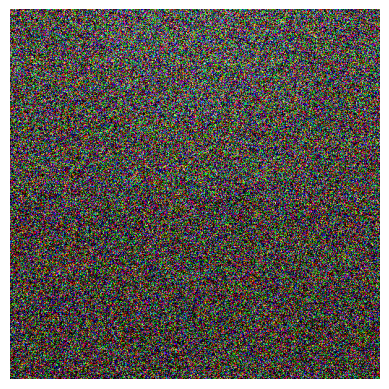

In [47]:
def generateNewImage(text, B = 1, NSTEPS = 50):
    textEmbed = concatenateTextEmbeddings(text)
    trmModel.eval()
    with torch.no_grad():
        xt = torch.randn(B, 3, 512, 512).to(device)
        textEmbed = textEmbed.to(device)        
        dt = 1.0 / NSTEPS

        for i in range(NSTEPS):
            t = torch.full((1,), i / NSTEPS, device=device)
            x, y, z, sharedParameters = trmModel.module.forward_init(
                xt, textEmbed, t
            )
            y, z, yOutput = deepReasoning(
                trmModel.module,
                x, y, z,
                sharedParameters,
                n=6,
                T=3
            )

            # predicted velocity ≈ (x1 - x0)
            v = yOutput   

            # Euler step
            xt = xt + dt * v

    return xt


xt = generateNewImage("A large passenger airplane flying through the air.", B = 1, NSTEPS= 100)
img = xt[0]
print(img.shape)
img = img.permute(1, 2, 0) 
print(img.shape)
plt.imshow(img)
plt.axis("off")
plt.show()
